# Lab: Decision Trees, Random Forests, and XGBoost
## Machine Learning for MBA Students

In this lab, you will learn about three important machine learning techniques:
- **Decision Trees**: Simple, interpretable models that make decisions using if-then rules
- **Random Forests**: Combines many decision trees to improve predictions
- **XGBoost**: A powerful gradient boosting algorithm that builds trees sequentially

We'll use the famous Titanic dataset to predict passenger survival.

## 1. Load Packages and Data

First, let's import the libraries we'll need and load our data.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For decision trees
from sklearn.tree import DecisionTreeClassifier, plot_tree

# For random forests
from sklearn.ensemble import RandomForestClassifier

# For XGBoost
import xgboost as xgb

# For model evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set random seed for reproducibility
np.random.seed(1818)

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries loaded successfully!")

/Users/matthewtonks/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/cg/drmdpssj7b1g61ncm5ng3gww0000gn/T/matplotlib-ab4ttks_ because there was an issue with the default path (/Users/matthewtonks/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


In [2]:
# Load the Titanic dataset
# We'll use seaborn's built-in titanic dataset
titanic_df = sns.load_dataset('titanic')

# Display the first few rows
print("First 5 rows of the dataset:")
print(titanic_df.head())

print("\nDataset shape:", titanic_df.shape)
print("\nColumn information:")
print(titanic_df.info())

First 5 rows of the dataset:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset shape: (891, 15)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtyp

## 2. Explore the Data

Let's understand our data better by looking at correlations and basic statistics.

In [3]:
# Basic statistics
print("Summary statistics:")
print(titanic_df.describe())

# Check for missing values
print("\nMissing values per column:")
print(titanic_df.isnull().sum())

Summary statistics:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
ali

Survival rate:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


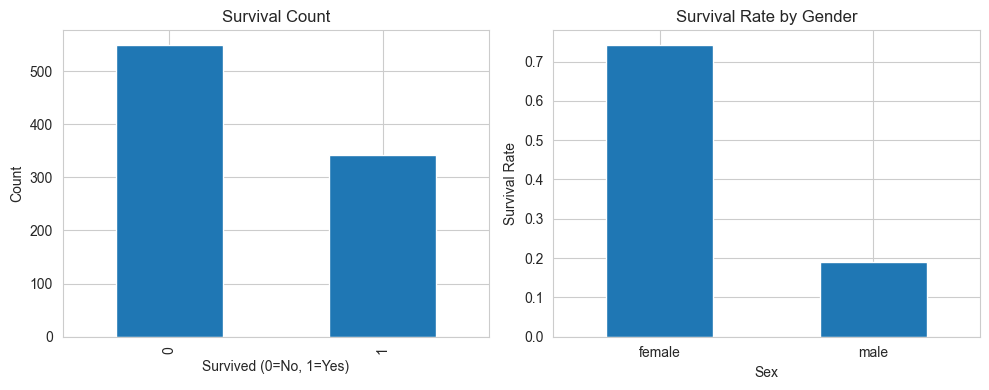

In [4]:
# Survival rate
print("Survival rate:")
print(titanic_df['survived'].value_counts(normalize=True))

# Visualize survival rate
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
titanic_df['survived'].value_counts().plot(kind='bar')
plt.title('Survival Count')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
titanic_df.groupby('sex')['survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Gender')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

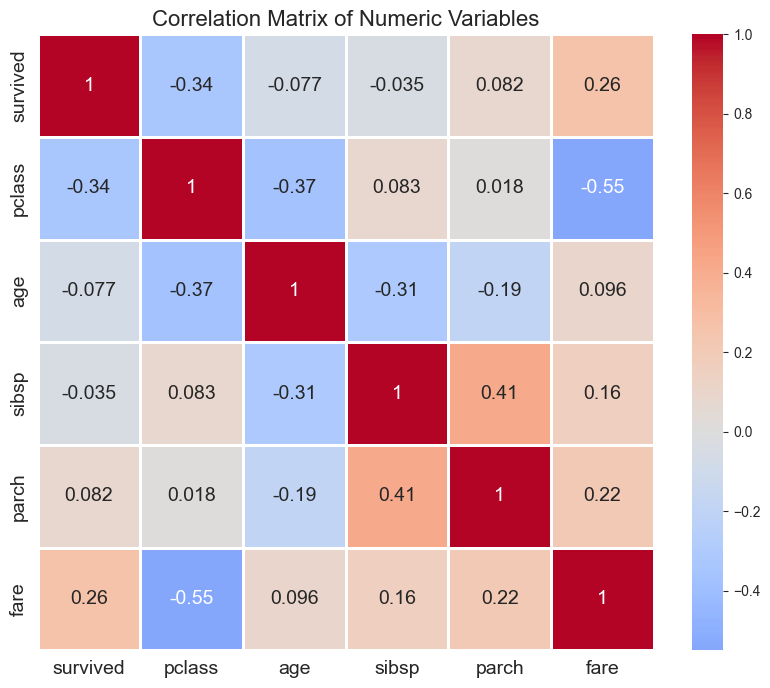

In [5]:
# Create a correlation heatmap for numeric variables
numeric_cols = titanic_df.select_dtypes(include=[np.number]).columns
correlation_matrix = titanic_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1,
            annot_kws={'fontsize': 14})  # Font size for correlation values
plt.title('Correlation Matrix of Numeric Variables', fontsize=16)  # Title font size
plt.xticks(fontsize=14)  # X-axis labels font size
plt.yticks(fontsize=14)  # Y-axis labels font size
plt.show()

## 3. Prepare the Data

We need to clean and prepare our data for modeling.

In [6]:
# Select relevant columns and clean the data
# We'll keep it simple for beginners
titanic_clean = titanic_df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].copy()

# Convert sex to numeric (0=female, 1=male)
titanic_clean['sex'] = titanic_clean['sex'].map({'female': 0, 'male': 1})

# Fill missing ages with the median age
titanic_clean['age'].fillna(titanic_clean['age'].median(), inplace=True)

# Fill missing fares with the median fare
titanic_clean['fare'].fillna(titanic_clean['fare'].median(), inplace=True)

# Remove any remaining rows with missing values
titanic_clean = titanic_clean.dropna()

print("Cleaned dataset shape:", titanic_clean.shape)
print("\nFirst few rows of cleaned data:")
print(titanic_clean.head())

Cleaned dataset shape: (891, 7)

First few rows of cleaned data:
   survived  pclass  sex   age  sibsp  parch     fare
0         0       3    1  22.0      1      0   7.2500
1         1       1    0  38.0      1      0  71.2833
2         1       3    0  26.0      0      0   7.9250
3         1       1    0  35.0      1      0  53.1000
4         0       3    1  35.0      0      0   8.0500


/var/folders/cg/drmdpssj7b1g61ncm5ng3gww0000gn/T/ipykernel_71342/3511097001.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_clean['age'].fillna(titanic_clean['age'].median(), inplace=True)
/var/folders/cg/drmdpssj7b1g61ncm5ng3gww0000gn/T/ipykernel_71342/3511097001.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

In [7]:
# Separate features (X) and target (y)
X = titanic_clean.drop('survived', axis=1)
y = titanic_clean['survived']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1818)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 712 samples
Testing set size: 179 samples


## 4. Decision Trees

A decision tree makes predictions by asking a series of yes/no questions about the features.

### Simple Decision Tree

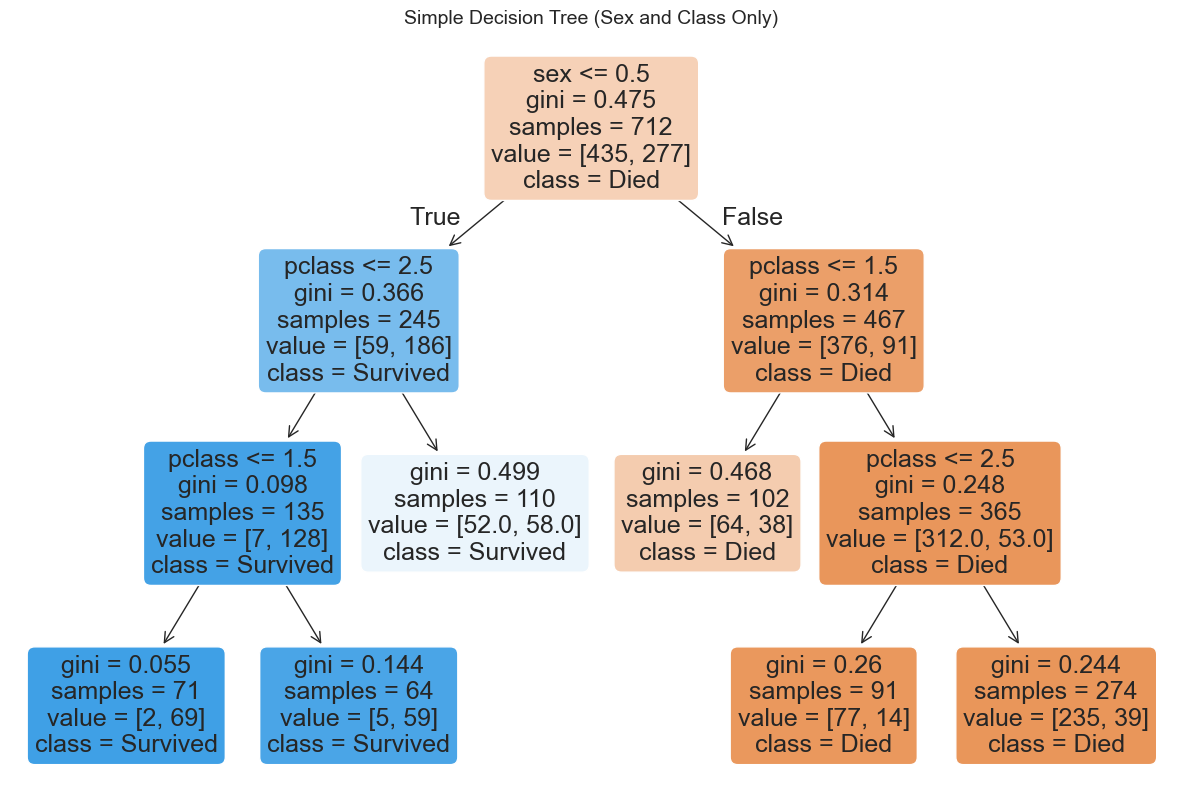


Simple Tree Accuracy: 0.777


In [8]:
# Create a simple decision tree (using only sex and class)
simple_tree = DecisionTreeClassifier(max_depth=3, random_state=1818)
simple_tree.fit(X_train[['pclass', 'sex']], y_train)

# Visualize the tree
plt.figure(figsize=(15, 10))
plot_tree(simple_tree, 
          feature_names=['pclass', 'sex'],
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=18)
plt.title('Simple Decision Tree (Sex and Class Only)', fontsize=14)
plt.show()

# Make predictions
simple_pred = simple_tree.predict(X_test[['pclass', 'sex']])
print(f"\nSimple Tree Accuracy: {accuracy_score(y_test, simple_pred):.3f}")

### More Complex Decision Tree

Now let's use all our features and control the tree's complexity.

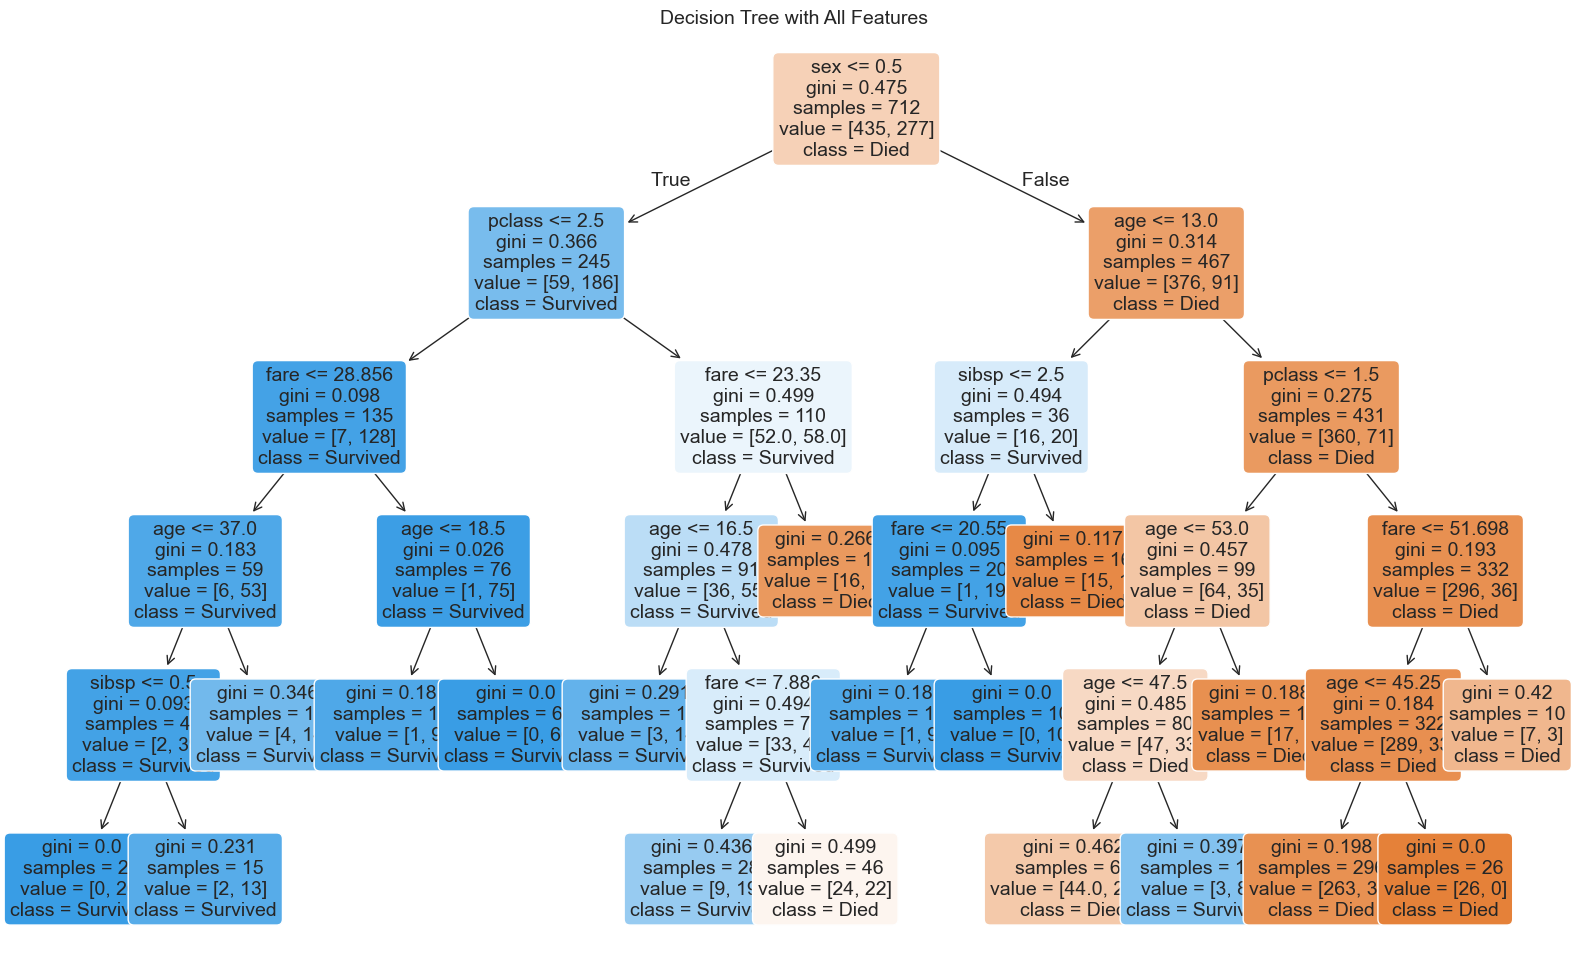


Decision Tree Accuracy: 0.832


In [9]:
# Create a more complex decision tree with all features
# max_depth: maximum number of levels in the tree
# min_samples_split: minimum number of samples required to split a node
# min_samples_leaf: minimum number of samples required in a leaf node

tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=1818
)

tree_model.fit(X_train, y_train)

# Visualize the tree
plt.figure(figsize=(20, 12))
plot_tree(tree_model, 
          feature_names=X.columns,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=14)
plt.title('Decision Tree with All Features', fontsize=14)
plt.show()

# Make predictions
tree_pred = tree_model.predict(X_test)
print(f"\nDecision Tree Accuracy: {accuracy_score(y_test, tree_pred):.3f}")

Feature Importance:
  feature  importance
1     sex    0.583284
0  pclass    0.174591
2     age    0.108870
3   sibsp    0.081728
5    fare    0.051527
4   parch    0.000000


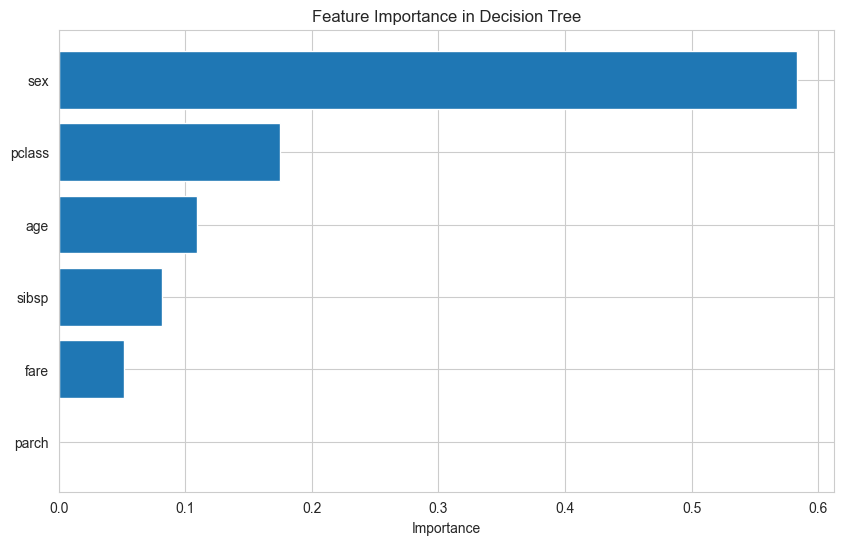

In [10]:
# Feature importance: which features matter most?
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': tree_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()
plt.show()

### Finding the Optimal Tree Depth

Let's use cross-validation to find the best tree depth.

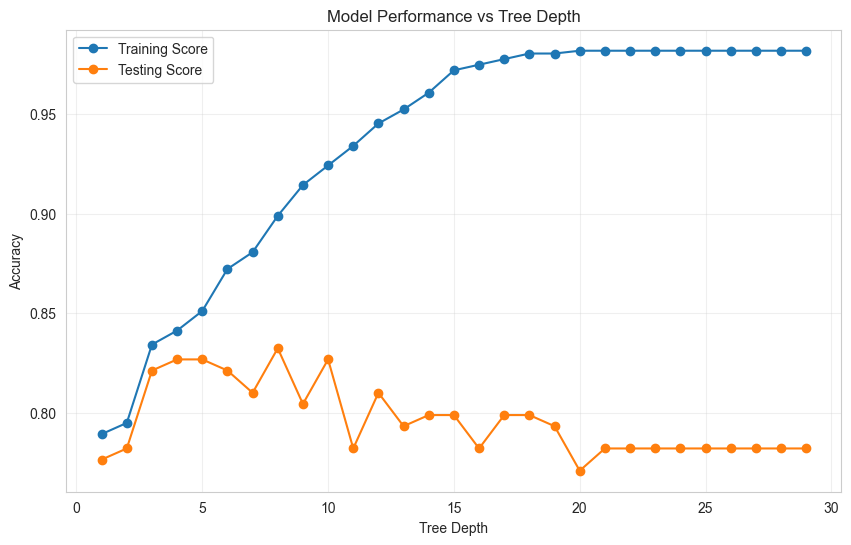


Best tree depth: 8
Best test accuracy: 0.832


In [11]:
# Test different tree depths
depths = range(1, 30)
train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=1818)
    tree.fit(X_train, y_train)
    
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Training Score', marker='o')
plt.plot(depths, test_scores, label='Testing Score', marker='o')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Model Performance vs Tree Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_depth = depths[np.argmax(test_scores)]
print(f"\nBest tree depth: {best_depth}")
print(f"Best test accuracy: {max(test_scores):.3f}")

## 5. Decision Tree Lab

**Exercise 1:** Create a decision tree using sex, pclass, age, sibsp, and fare. Set max_depth=4 and min_samples_leaf=15. What is the accuracy?

**Exercise 2:** Try different values of max_depth (3, 5, 7). Which combination works best?

**Exercise 3:** Based on your trees, who has the best chance of survival? Explain in business terms.

**Exercise 4:** What happens when you set max_depth=20? Why might this be a problem?

In [12]:
# Exercise 1: Your code here

tree_4 = DecisionTreeClassifier(max_depth=4, min_samples_leaf=15, random_state=1818)
tree_4.fit(X_train[['pclass', 'sex', 'age', 'sibsp', 'fare']], y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1818
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
# Exercise 2: Your code here

tree_3 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=1818)
tree_3.fit(X_train[['pclass', 'sex', 'age', 'sibsp', 'fare']], y_train)
tree_5 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=15, random_state=1818)
tree_5.fit(X_train[['pclass', 'sex', 'age', 'sibsp', 'fare']], y_train)
tree_8 = DecisionTreeClassifier(max_depth=8, min_samples_leaf=15, random_state=1818)
tree_8.fit(X_train[['pclass', 'sex', 'age', 'sibsp', 'fare']], y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1818
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


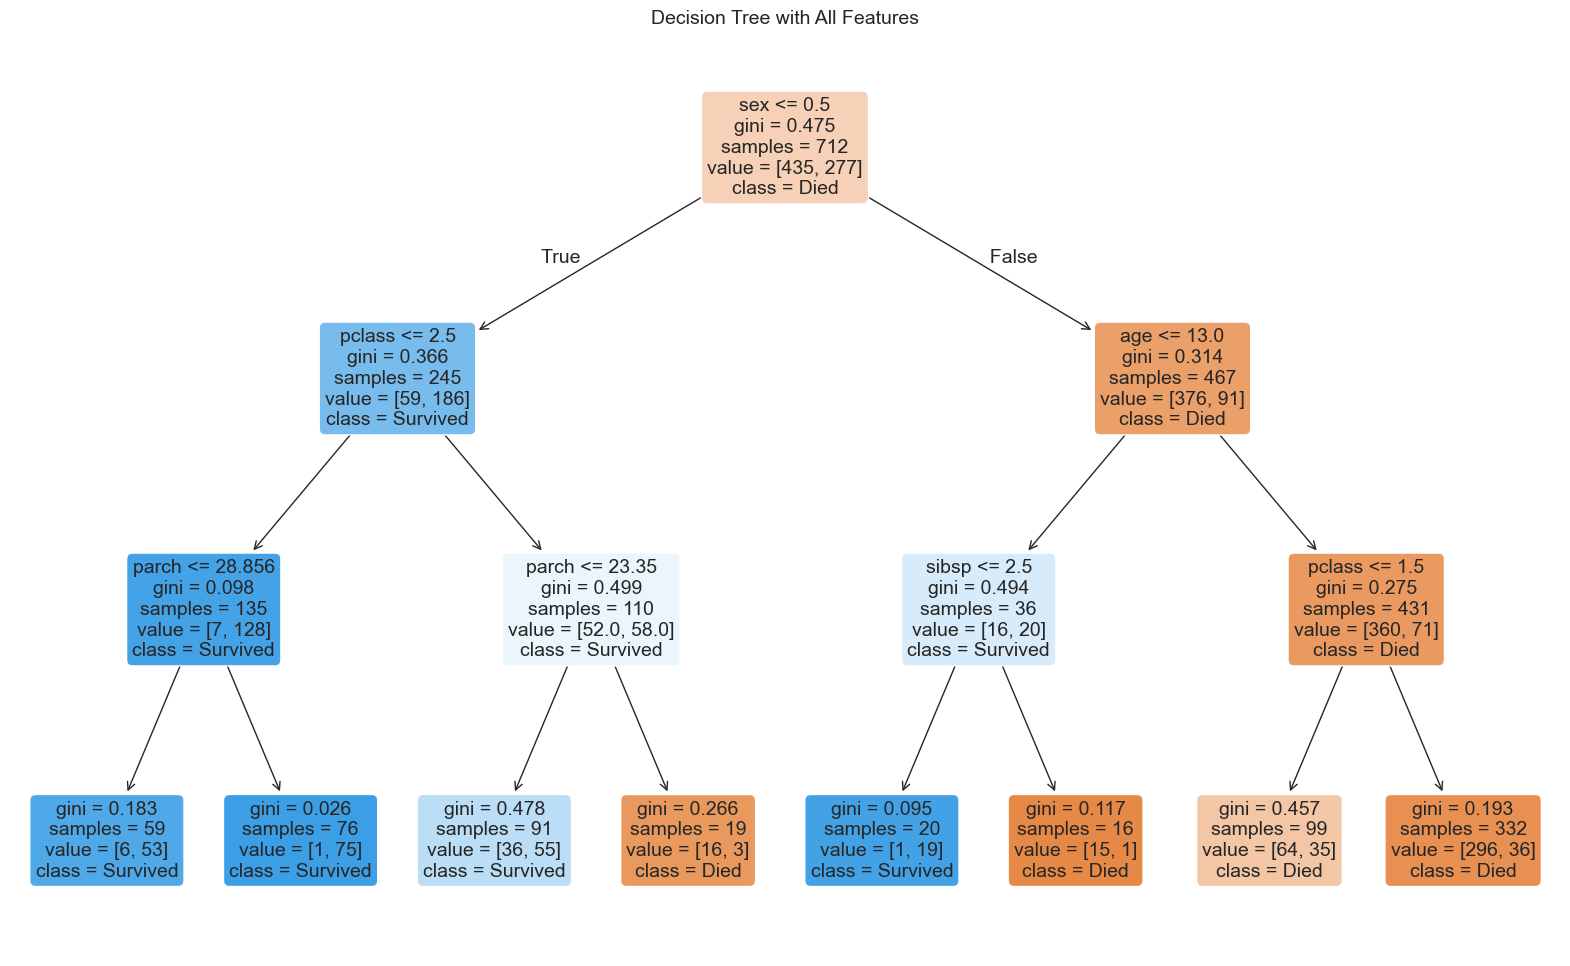

In [14]:
# Exercise 3: Your code here

plt.figure(figsize=(20, 12))
plot_tree(tree_3, 
          feature_names=X.columns,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=14)
plt.title('Decision Tree with All Features', fontsize=14)
plt.show()

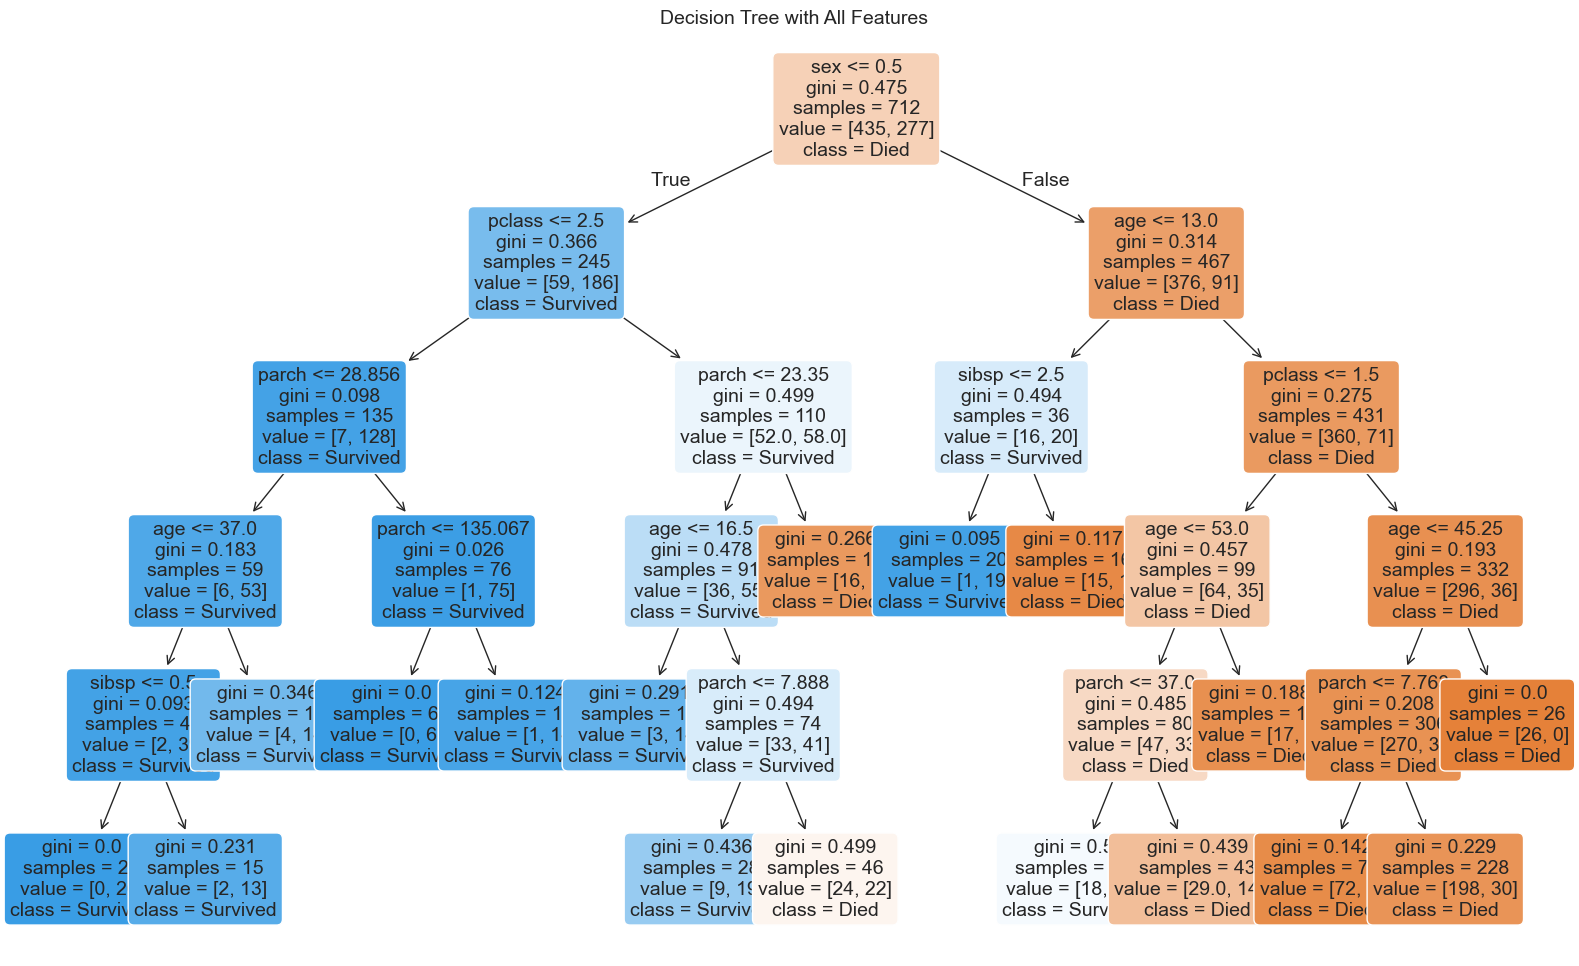

In [15]:

plt.figure(figsize=(20, 12))
plot_tree(tree_5, 
          feature_names=X.columns,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=14)
plt.title('Decision Tree with All Features', fontsize=14)
plt.show()

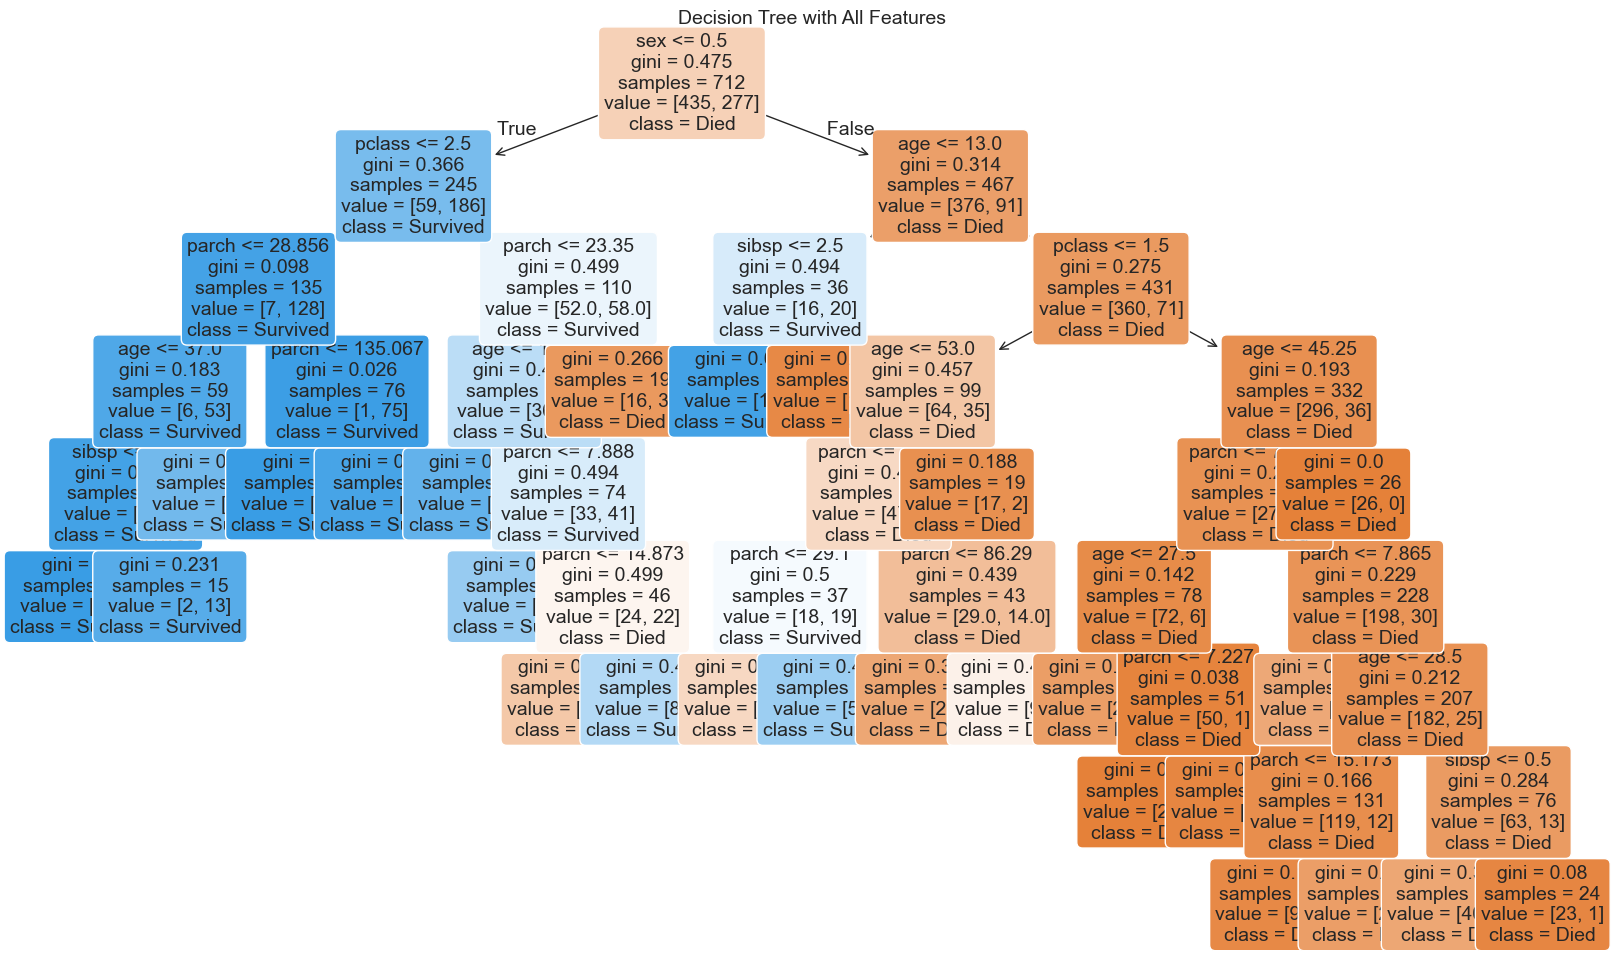

In [16]:

plt.figure(figsize=(20, 12))
plot_tree(tree_8, 
          feature_names=X.columns,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=14)
plt.title('Decision Tree with All Features', fontsize=14)
plt.show()

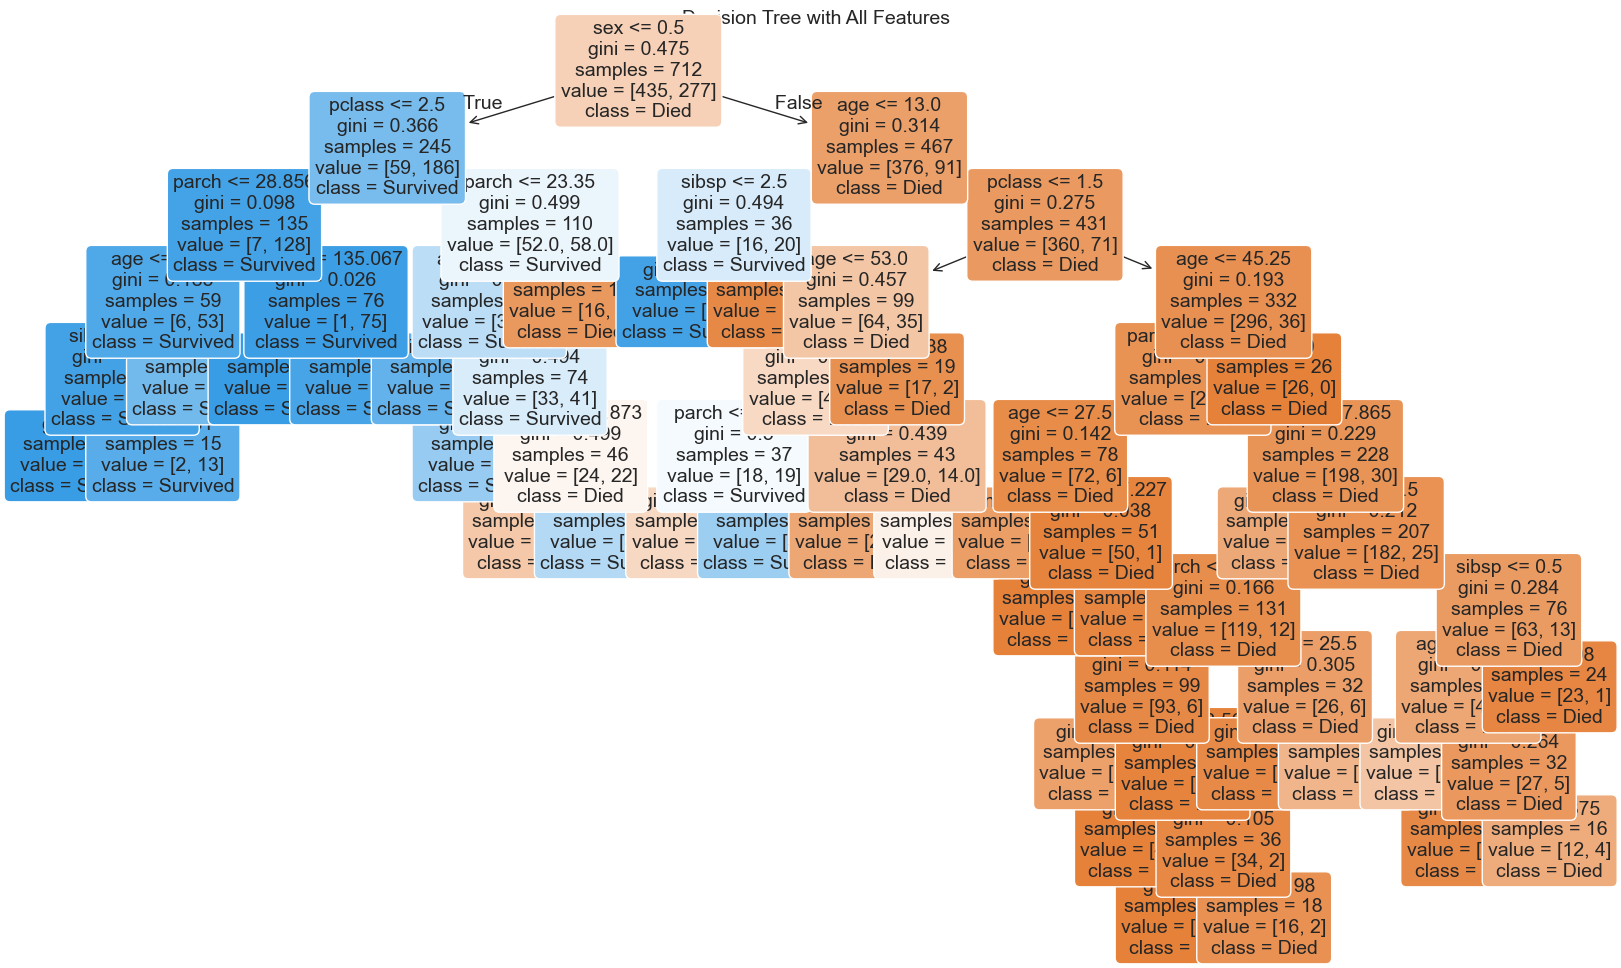

In [17]:
# Exercise 4: Your code here

tree_20 = DecisionTreeClassifier(max_depth=20, min_samples_leaf=15, random_state=1818)
tree_20.fit(X_train[['pclass', 'sex', 'age', 'sibsp', 'fare']], y_train)
plt.figure(figsize=(20, 12))
plot_tree(tree_20, 
          feature_names=X.columns,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=14)
plt.title('Decision Tree with All Features', fontsize=14)
plt.show()

## 6. Random Forests

Random Forests combine many decision trees to make better predictions. Each tree is trained on a random subset of the data and features.

**Key Parameters:**
- `n_estimators`: Number of trees in the forest
- `max_features`: Number of features to consider when looking for the best split
- `max_depth`: Maximum depth of each tree

In [18]:
# Create a Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=600,      # Number of trees
    max_features=3,        # Number of features to consider at each split
    random_state=1818,
    n_jobs=-1              # Use all CPU cores
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Died', 'Survived']))

Random Forest Accuracy: 0.832

Classification Report:
              precision    recall  f1-score   support

        Died       0.86      0.89      0.87       114
    Survived       0.79      0.74      0.76        65

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



Random Forest Feature Importance:
  feature  importance
1     sex    0.281829
5    fare    0.280214
2     age    0.270344
0  pclass    0.081699
3   sibsp    0.052795
4   parch    0.033118


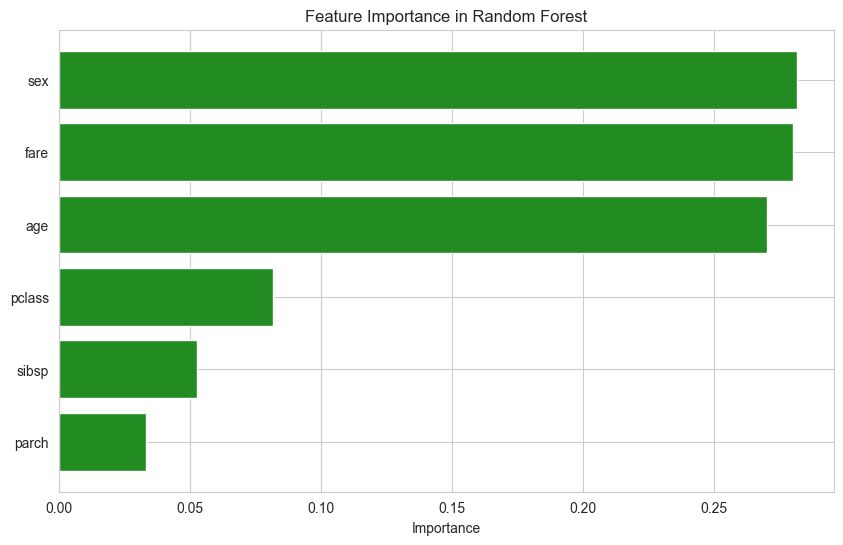

In [19]:
# Feature importance from Random Forest
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Random Forest Feature Importance:")
print(rf_feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance['feature'], rf_feature_importance['importance'], color='forestgreen')
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest')
plt.gca().invert_yaxis()
plt.show()

### Tuning Random Forests

Let's find the optimal number of features to use at each split (max_features).

max_features=1, Accuracy: 0.832
max_features=2, Accuracy: 0.838
max_features=3, Accuracy: 0.832
max_features=4, Accuracy: 0.816
max_features=5, Accuracy: 0.799
max_features=6, Accuracy: 0.816


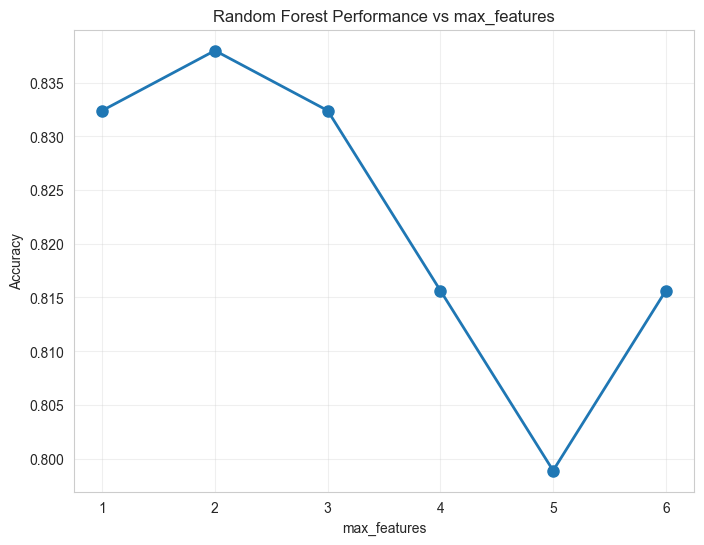


Best max_features: 2
Best accuracy: 0.838


In [20]:
# Test different values of max_features
max_features_range = range(1, len(X.columns) + 1)
accuracies = []

for max_feat in max_features_range:
    rf = RandomForestClassifier(
        n_estimators=600,
        max_features=max_feat,
        random_state=1818,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    accuracy = rf.score(X_test, y_test)
    accuracies.append(accuracy)
    print(f"max_features={max_feat}, Accuracy: {accuracy:.3f}")

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(max_features_range, accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('max_features')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance vs max_features')
plt.grid(True, alpha=0.3)
plt.xticks(max_features_range)
plt.show()

best_max_features = max_features_range[np.argmax(accuracies)]
print(f"\nBest max_features: {best_max_features}")
print(f"Best accuracy: {max(accuracies):.3f}")

## 7. Random Forest Exercises

**Exercise 1:** Create a Random Forest with n_estimators=400 and max_features=5. What accuracy do you get?

**Exercise 2:** Compare the feature importance from your decision tree vs. random forest. Are they similar?

**Exercise 3:** Try n_estimators values of 100, 300, and 600. Does more trees always improve performance?

**Exercise 4:** Why might Random Forest perform better than a single decision tree?

In [21]:
# Exercise 1: Your code here
rf = RandomForestClassifier(
        n_estimators=400,
        max_features=5,
        random_state=1818,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
print(rf.score(X_test, y_test))

0.8044692737430168


Random Forest Feature Importance:
  feature  importance
1     sex    0.304595
2     age    0.263132
5    fare    0.258481
0  pclass    0.088968
3   sibsp    0.058606
4   parch    0.026218


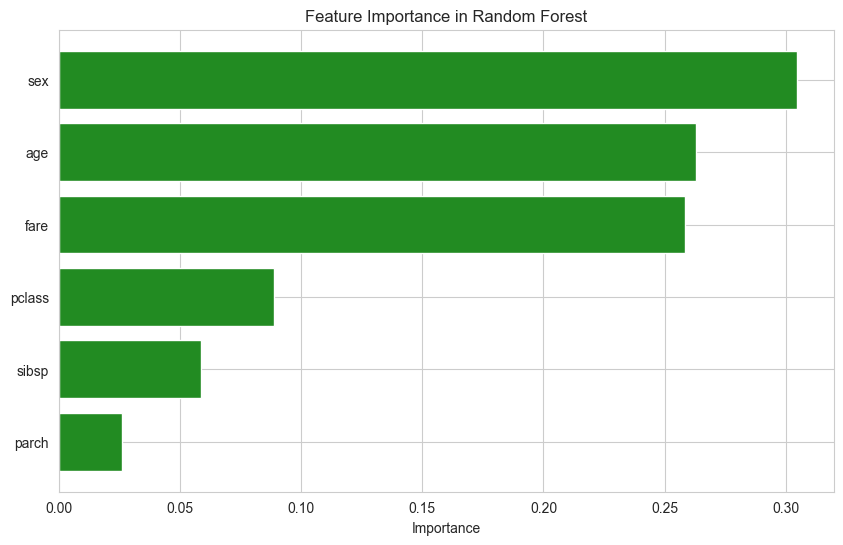

In [22]:
# Exercise 2: Your code here
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Random Forest Feature Importance:")
print(rf_feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance['feature'], rf_feature_importance['importance'], color='forestgreen')
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [23]:
# Exercise 3: Your code here
rf = RandomForestClassifier(
        n_estimators=100,
        max_features=5,
        random_state=1818,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
print(rf.score(X_test, y_test))
rf = RandomForestClassifier(
        n_estimators=300,
        max_features=5,
        random_state=1818,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
print(rf.score(X_test, y_test))
rf = RandomForestClassifier(
        n_estimators=600,
        max_features=5,
        random_state=1818,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
print(rf.score(X_test, y_test))

0.8156424581005587
0.8100558659217877
0.7988826815642458


In [24]:
# Exercise 4: Your code here


Combines multiple iterations of multiple trees to get the best model from approaching the datasets meaning there is a more complete view of the data being shown

## 8. XGBoost (Extreme Gradient Boosting)

XGBoost is a powerful machine learning algorithm that builds trees sequentially. Each new tree tries to correct the mistakes of the previous trees.

**Key Differences from Random Forest:**
- Random Forest: Trees are independent (built in parallel)
- XGBoost: Trees are dependent (built sequentially, learning from previous errors)

**Key Parameters:**
- `n_estimators`: Number of boosting rounds (trees to build)
- `max_depth`: Maximum depth of each tree
- `learning_rate`: How much each tree contributes (smaller = more conservative)
- `subsample`: Fraction of samples to use for each tree

In [25]:
# Create an XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,         # Number of boosting rounds
    max_depth=3,              # Maximum tree depth
    learning_rate=0.1,        # Step size shrinkage
    subsample=0.8,            # Subsample ratio of training data
    colsample_bytree=0.8,     # Subsample ratio of features
    random_state=1818,
    eval_metric='logloss'     # Evaluation metric
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluate the model
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Died', 'Survived']))

XGBoost Accuracy: 0.821

Classification Report:
              precision    recall  f1-score   support

        Died       0.84      0.89      0.86       114
    Survived       0.78      0.71      0.74        65

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



XGBoost Feature Importance:
  feature  importance
1     sex    0.597418
0  pclass    0.149993
3   sibsp    0.081840
2     age    0.062492
5    fare    0.058997
4   parch    0.049260


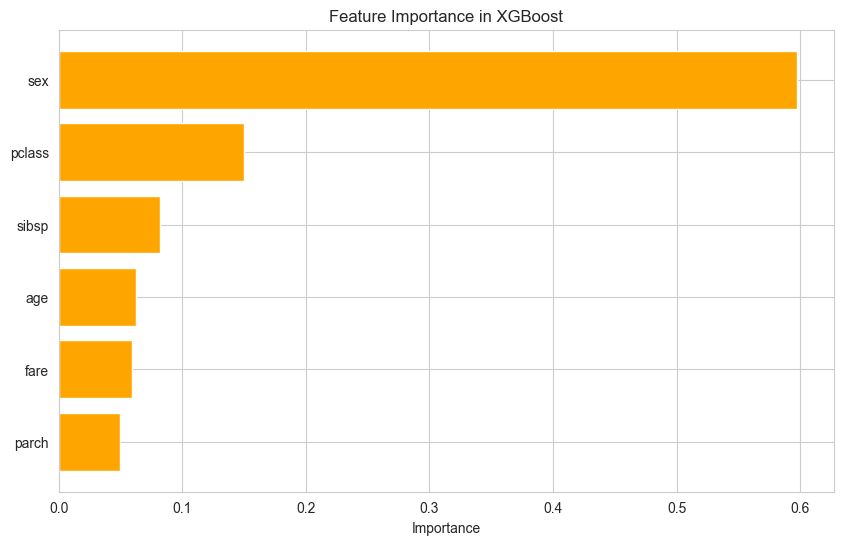

In [26]:
# XGBoost feature importance
xgb_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("XGBoost Feature Importance:")
print(xgb_feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(xgb_feature_importance['feature'], xgb_feature_importance['importance'], color='orange')
plt.xlabel('Importance')
plt.title('Feature Importance in XGBoost')
plt.gca().invert_yaxis()
plt.show()

### Tuning XGBoost

Let's experiment with different learning rates and number of estimators.

In [46]:
# Test different learning rates and n_estimators
learning_rates = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 1.25, 1.5, 1.75]
n_estimators_list = [50, 100, 200, 400, 500, 600]

results = []

for lr in learning_rates:
    for n_est in n_estimators_list:
        xgb_temp = xgb.XGBClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=3,
            random_state=1818,
            eval_metric='logloss'
        )
        xgb_temp.fit(X_train, y_train)
        accuracy = xgb_temp.score(X_test, y_test)
        results.append({
            'learning_rate': lr,
            'n_estimators': n_est,
            'accuracy': accuracy
        })
        print(f"LR={lr}, n_est={n_est}, Accuracy: {accuracy:.3f}")

results_df = pd.DataFrame(results)
print("\nBest parameters:")
best_result = results_df.loc[results_df['accuracy'].idxmax()]
print(best_result)

LR=0.01, n_est=50, Accuracy: 0.816
LR=0.01, n_est=100, Accuracy: 0.810
LR=0.01, n_est=200, Accuracy: 0.832
LR=0.01, n_est=400, Accuracy: 0.832
LR=0.01, n_est=500, Accuracy: 0.827
LR=0.01, n_est=600, Accuracy: 0.804
LR=0.05, n_est=50, Accuracy: 0.827
LR=0.05, n_est=100, Accuracy: 0.816
LR=0.05, n_est=200, Accuracy: 0.827
LR=0.05, n_est=400, Accuracy: 0.827
LR=0.05, n_est=500, Accuracy: 0.827
LR=0.05, n_est=600, Accuracy: 0.844
LR=0.1, n_est=50, Accuracy: 0.827
LR=0.1, n_est=100, Accuracy: 0.821
LR=0.1, n_est=200, Accuracy: 0.827
LR=0.1, n_est=400, Accuracy: 0.838
LR=0.1, n_est=500, Accuracy: 0.849
LR=0.1, n_est=600, Accuracy: 0.844
LR=0.3, n_est=50, Accuracy: 0.821
LR=0.3, n_est=100, Accuracy: 0.832
LR=0.3, n_est=200, Accuracy: 0.838
LR=0.3, n_est=400, Accuracy: 0.844
LR=0.3, n_est=500, Accuracy: 0.844
LR=0.3, n_est=600, Accuracy: 0.844
LR=0.5, n_est=50, Accuracy: 0.821
LR=0.5, n_est=100, Accuracy: 0.849
LR=0.5, n_est=200, Accuracy: 0.832
LR=0.5, n_est=400, Accuracy: 0.838
LR=0.5, n_est

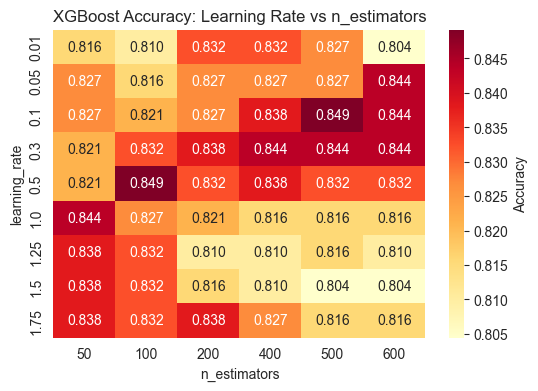

In [47]:
# Visualize the tuning results
pivot_table = results_df.pivot(index='learning_rate', columns='n_estimators', values='accuracy')

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Accuracy'})
plt.title('XGBoost Accuracy: Learning Rate vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('learning_rate')
plt.show()

## 9. Model Comparison

Let's compare all three models side by side.

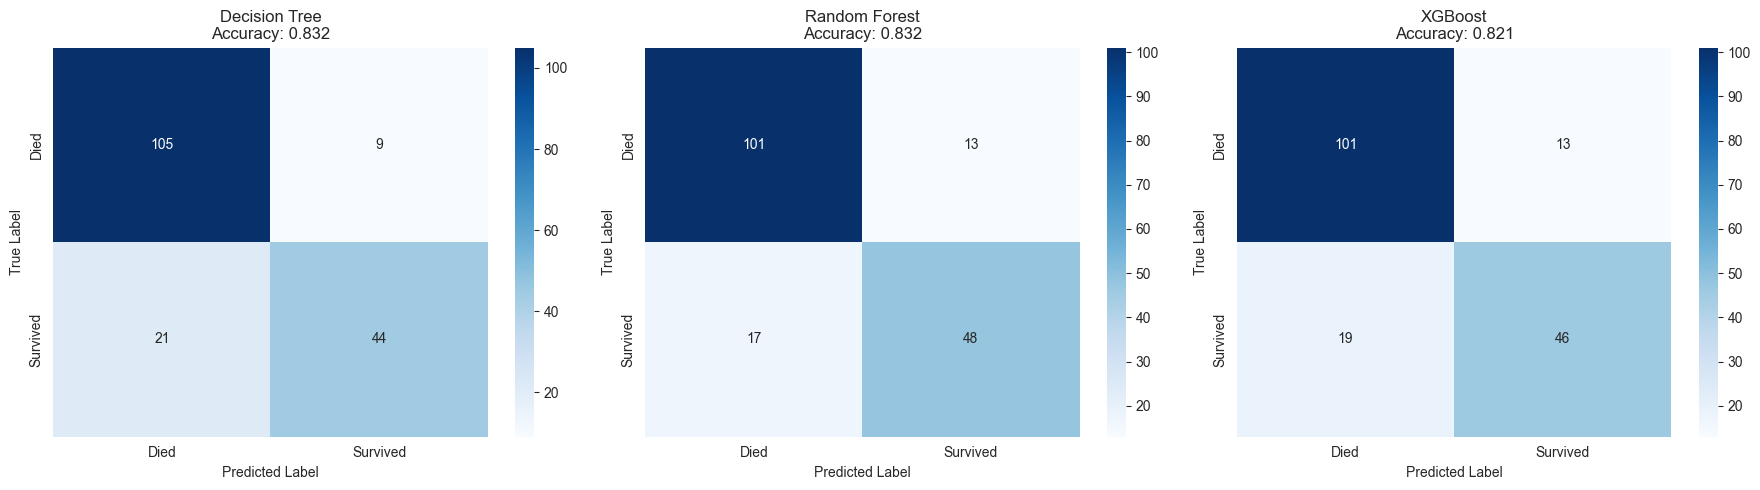

In [29]:
# Create confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Decision Tree', tree_pred),
    ('Random Forest', rf_pred),
    ('XGBoost', xgb_pred)
]

for idx, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Died', 'Survived'],
                yticklabels=['Died', 'Survived'])
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.3f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

Model Performance Comparison:
           Model  Accuracy
0  Decision Tree  0.832402
1  Random Forest  0.832402
2        XGBoost  0.821229


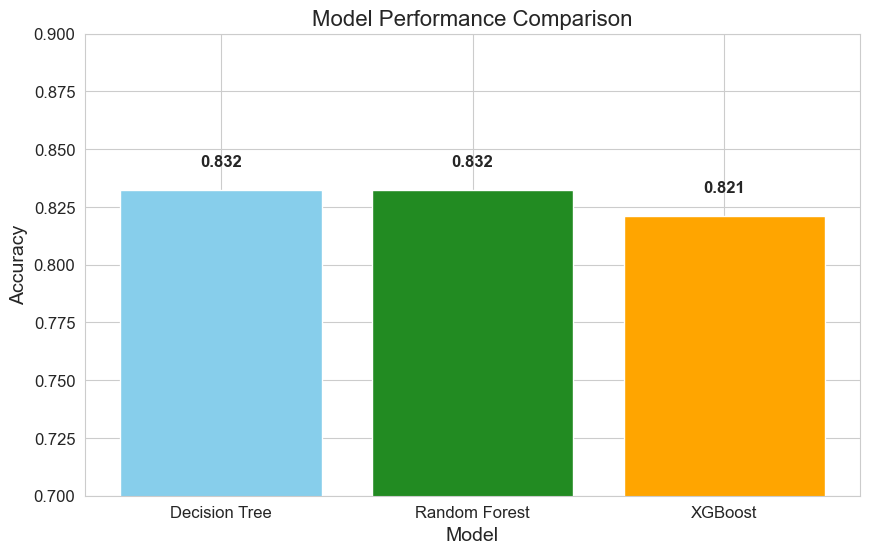

In [30]:
# Compare model accuracies
model_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
}).sort_values('Accuracy', ascending=False)

print("Model Performance Comparison:")
print(model_comparison)

# Visualize comparison
plt.figure(figsize=(10, 6))
plt.bar(model_comparison['Model'], model_comparison['Accuracy'], 
        color=['skyblue', 'forestgreen', 'orange'])
plt.ylabel('Accuracy', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.title('Model Performance Comparison', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim([0.7, 0.9])
for i, v in enumerate(model_comparison['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=12)
plt.show()

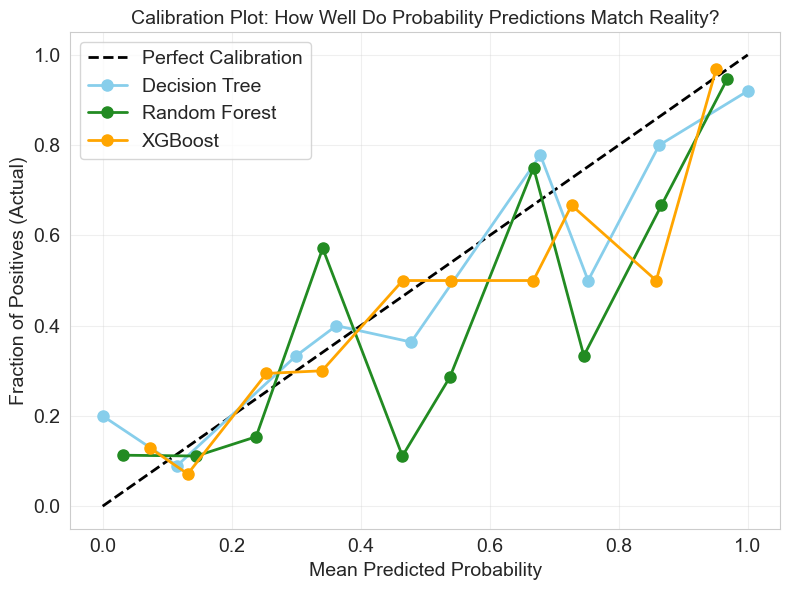


Calibration Interpretation:
• Points close to diagonal = well calibrated
• Above diagonal = model is under-confident (actual rate higher than predicted)
• Below diagonal = model is over-confident (actual rate lower than predicted)


In [31]:
from sklearn.calibration import calibration_curve

# Get probability predictions from each model
tree_probs = tree_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate calibration curves
tree_fraction, tree_mean = calibration_curve(y_test, tree_probs, n_bins=10)
rf_fraction, rf_mean = calibration_curve(y_test, rf_probs, n_bins=10)
xgb_fraction, xgb_mean = calibration_curve(y_test, xgb_probs, n_bins=10)

# Plot calibration curves
plt.figure(figsize=(8, 6))

# Perfect calibration line
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)

# Model calibration curves
plt.plot(tree_mean, tree_fraction, 'o-', label='Decision Tree', 
         color='skyblue', linewidth=2, markersize=8)
plt.plot(rf_mean, rf_fraction, 'o-', label='Random Forest', 
         color='forestgreen', linewidth=2, markersize=8)
plt.plot(xgb_mean, xgb_fraction, 'o-', label='XGBoost', 
         color='orange', linewidth=2, markersize=8)

plt.xlabel('Mean Predicted Probability', fontsize=14)
plt.ylabel('Fraction of Positives (Actual)', fontsize=14)
plt.title('Calibration Plot: How Well Do Probability Predictions Match Reality?', fontsize=14)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

print("\nCalibration Interpretation:")
print("• Points close to diagonal = well calibrated")
print("• Above diagonal = model is under-confident (actual rate higher than predicted)")
print("• Below diagonal = model is over-confident (actual rate lower than predicted)")

## 10. XGBoost Exercises

**Exercise 1:** Create an XGBoost model with n_estimators=150, learning_rate=0.05, and max_depth=4. How does it perform?

**Exercise 2:** What happens when you increase max_depth to 10? Why might this be a problem?

**Exercise 3:** Compare feature importance across all three models. Which features are consistently important?

**Exercise 4:** Based on your results, which model would you recommend for predicting Titanic survival? Explain your reasoning considering both accuracy and interpretability.

In [32]:
# Exercise 1: Your code here
xgb_model = xgb.XGBClassifier(
    n_estimators=150,         # Number of boosting rounds
    max_depth=4,              # Maximum tree depth
    learning_rate=0.05,        # Step size shrinkage
    subsample=0.8,            # Subsample ratio of training data
    colsample_bytree=0.8,     # Subsample ratio of features
    random_state=1818,
    eval_metric='logloss'     # Evaluation metric
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluate the model
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Died', 'Survived']))

XGBoost Accuracy: 0.827

Classification Report:
              precision    recall  f1-score   support

        Died       0.85      0.88      0.87       114
    Survived       0.77      0.74      0.76        65

    accuracy                           0.83       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



In [33]:
# Exercise 2: Your code here
xgb_model = xgb.XGBClassifier(
    n_estimators=150,         # Number of boosting rounds
    max_depth=10,              # Maximum tree depth
    learning_rate=0.05,        # Step size shrinkage
    subsample=0.8,            # Subsample ratio of training data
    colsample_bytree=0.8,     # Subsample ratio of features
    random_state=1818,
    eval_metric='logloss'     # Evaluation metric
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluate the model
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Died', 'Survived']))

XGBoost Accuracy: 0.832

Classification Report:
              precision    recall  f1-score   support

        Died       0.86      0.89      0.87       114
    Survived       0.79      0.74      0.76        65

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



  Feature  Decision Tree  Random Forest   XGBoost
0  pclass       0.174591       0.081699  0.111144
1     sex       0.583284       0.281829  0.696222
2     age       0.108870       0.270344  0.047165
3   sibsp       0.081728       0.052795  0.062053
4   parch       0.000000       0.033118  0.041949
5    fare       0.051527       0.280214  0.041468


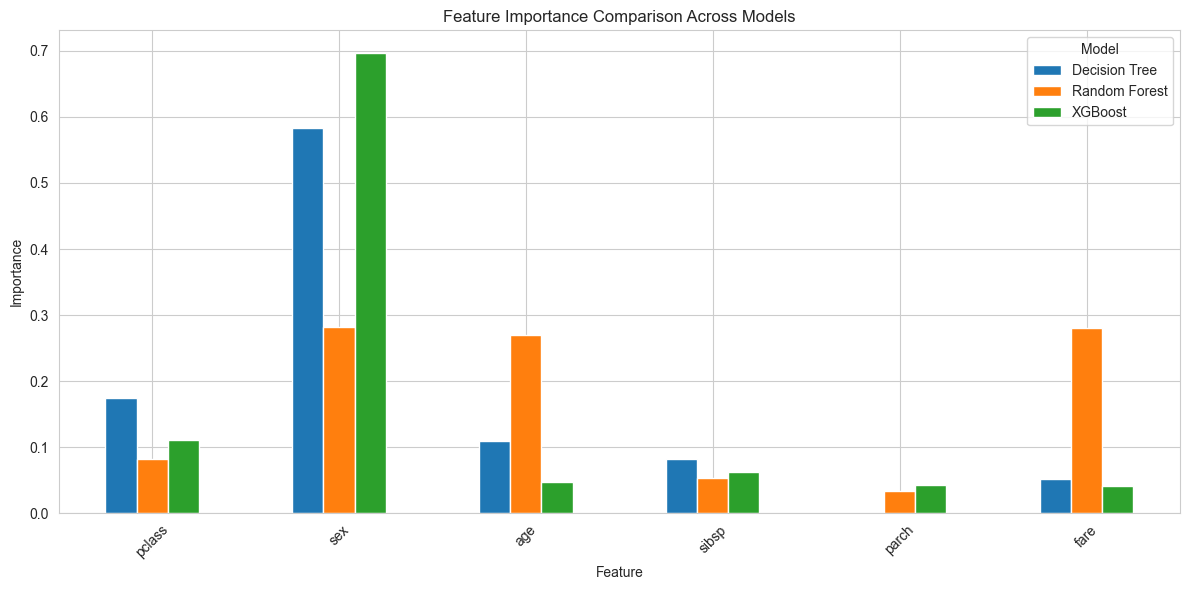

In [34]:
# Exercise 3: Compare feature importance
comparison_df = pd.DataFrame({
    'Feature': X.columns,
    'Decision Tree': tree_model.feature_importances_,
    'Random Forest': rf_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_
})

print(comparison_df)

# Visualize
comparison_df.set_index('Feature').plot(kind='bar', figsize=(12, 6))
plt.title('Feature Importance Comparison Across Models')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.legend(title='Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Key Takeaways

### Decision Trees
- **Pros:** Easy to interpret and visualize, handles non-linear relationships
- **Cons:** Can overfit easily, unstable (small data changes can drastically change the tree)
- **Best for:** When you need an explainable model

### Random Forests
- **Pros:** More accurate than single trees, reduces overfitting, handles many features well
- **Cons:** Less interpretable, slower to train and predict
- **Best for:** When accuracy is more important than interpretability

### XGBoost
- **Pros:** Often the most accurate, handles missing data, prevents overfitting through regularization
- **Cons:** More parameters to tune, can be slower to train, less interpretable
- **Best for:** Competitions, when you need the highest possible accuracy

### Business Insights from Our Analysis
1. **Gender matters most:** Being female dramatically increased survival chances
2. **Class matters:** First-class passengers had better survival rates
3. **Age is important:** Children and younger passengers had better chances
4. **Family size:** Traveling alone or with many family members decreased survival chances

## 12. Bonus: Making Predictions on New Data

Let's see how we would use our best model to make predictions on new passengers.

In [35]:
# Create hypothetical new passengers or yourself! 

new_passengers = pd.DataFrame({
    'pclass': [1, 3, 2, 3],
    'sex': [0, 1, 0, 1],  # 0=female, 1=male
    'age': [25, 30, 5, 45],
    'sibsp': [1, 0, 2, 0],
    'parch': [0, 0, 1, 0],
    'fare': [100, 8, 25, 10]
})

# Create descriptions
descriptions = [
    "Young woman, 1st class, with spouse",
    "30-year-old man, 3rd class, traveling alone",
    "5-year-old girl, 2nd class, with family",
    "Middle-aged man, 3rd class, traveling alone"
]

# Make predictions with all three models
tree_predictions = tree_model.predict(new_passengers)
rf_predictions = rf_model.predict(new_passengers)
xgb_predictions = xgb_model.predict(new_passengers)

# Get probability predictions from XGBoost
xgb_probabilities = xgb_model.predict_proba(new_passengers)[:, 1]

# Display results
results = pd.DataFrame({
    'Passenger': descriptions,
    'Decision Tree': ['Survived' if p == 1 else 'Died' for p in tree_predictions],
    'Random Forest': ['Survived' if p == 1 else 'Died' for p in rf_predictions],
    'XGBoost': ['Survived' if p == 1 else 'Died' for p in xgb_predictions],
    'Survival Probability': [f'{p:.1%}' for p in xgb_probabilities]
})

print("Predictions for New Passengers:")
print(results.to_string(index=False))

Predictions for New Passengers:
                                  Passenger Decision Tree Random Forest  XGBoost Survival Probability
        Young woman, 1st class, with spouse      Survived      Survived Survived                97.9%
30-year-old man, 3rd class, traveling alone          Died          Died     Died                38.0%
    5-year-old girl, 2nd class, with family      Survived      Survived Survived                93.6%
Middle-aged man, 3rd class, traveling alone          Died          Died     Died                18.6%


## Congratulations!

You've completed the lab on Decision Trees, Random Forests, and XGBoost. You now understand:

1. How decision trees make predictions using simple rules
2. How random forests combine many trees for better predictions
3. How XGBoost builds trees sequentially to correct errors
4. How to tune hyperparameters for each model
5. How to compare model performance and interpret results

These techniques are widely used in business for:
- Customer churn prediction
- Credit risk assessment
- Fraud detection
- Marketing response modeling
- And many more applications!